# Car Classification using Convolutional Neural Networks
---
<br>

### Name and ID:
Yoav Gal: 212832471
<br>
Guy Houri: 324970557

# Running The Notebook

1. **Installations** - Setting up the required libraries and dependencies.
2. **Data Preparation** - Process the data one time so it would be used later with ease and speed (no need to run it again).
Processing steps: Train test split to 70/30, converting images to grayscale,scaling images down, augmentation, save as tensors.
3. **Utilities** - Helper functions that would be used while training the models.
4. **Training Preperation**: Load Tensors. (only if training)
5. **Experiment 1 : Basic_CNN_GAP_MP** - This is a basic CNN model with Global Average Pooling and Max Pooling layers.
6. **Experiment 2 : QuickTrain** - A small model that uses depthwise separable convolutions, desinged for speed of and ease of training.
7. **Experiment 3 : BiggerIsBetter** - A bigger version of the Quick Train model.
8. **Test Best Model** - A small test envitoment to try out our best model (This enviorment is self contained, can be runed without any thing else).


**How to run?**
This notebook has 3 ways to run it.
1. Test - Just run the test environment.
2. Data Preperation - Run the Installations section then the Data Preparation section (remember to remove skips).
3. Train a model yourself - Run the Installations section then the Utilities and Training Preparation section and then run model you want to train (remember to remove skips).


# Installations

In [1]:
%%capture
%pip install scipy matplotlib pillow numpy pandas tqdm torch torchvision scikit-learn gdown kagglehub openpyxl tk ipython-autotime ipython albumentations
%load_ext autotime
%load_ext autoreload

time: 51.4 ms (started: 2025-03-13 07:04:32 +02:00)


In [ ]:
# %script echo skipping
!gdown 137XcFezg-_5Zf8RONqMuXpGYyAZELHVy #python code - data_utilts.py
!gdown 1RS_xIfS7lhJbx-IgXfXZiaBwQ8pEAF5U # cnn_train_tensors.zip
!gdown 1quaYbFJW5escES-IGRNNI3sxRReQ-4Hz # cnn_test_tensors.zip


Downloading...
From (original): https://drive.google.com/uc?id=137XcFezg-_5Zf8RONqMuXpGYyAZELHVy
From (redirected): https://drive.google.com/uc?id=137XcFezg-_5Zf8RONqMuXpGYyAZELHVy&confirm=t&uuid=904bace1-d6ab-4d2b-8338-96570a10604a
To: /content/data_utils.py
100% 2.10k/2.10k [00:00<00:00, 6.13MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RS_xIfS7lhJbx-IgXfXZiaBwQ8pEAF5U
From (redirected): https://drive.google.com/uc?id=1RS_xIfS7lhJbx-IgXfXZiaBwQ8pEAF5U&confirm=t&uuid=b1c44528-d0e0-46a7-aee9-570e3da68165
To: /content/cnn_train_tensors.zip
100% 1.21G/1.21G [00:16<00:00, 71.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1quaYbFJW5escES-IGRNNI3sxRReQ-4Hz
From (redirected): https://drive.google.com/uc?id=1quaYbFJW5escES-IGRNNI3sxRReQ-4Hz&confirm=t&uuid=7046a059-7303-4802-bdea-665506a5b0b0
To: /content/cnn_test_tensors.zip
100% 132M/132M [00:02<00:00, 45.4MB/s]
time: 31.8 s (started: 2025-03-10 15:02:31 +00:00)


In [ ]:
import kagglehub
path = kagglehub.dataset_download("jessicali9530/stanford-cars-dataset")

100%|██████████| 1.82G/1.82G [00:22<00:00, 85.4MB/s]

Extracting files...


time: 48.2 s (started: 2025-03-10 15:03:03 +00:00)


In [ ]:
!mkdir ./content
!mkdir ./content/images/
!mkdir ./content/images/test
!mkdir ./content/images/train

time: 417 ms (started: 2025-03-10 15:03:51 +00:00)


In [ ]:
!mv /root/.cache/kagglehub/datasets/jessicali9530/stanford-cars-dataset/versions/2/cars_test/cars_test/* ./content/images/test
!mv /root/.cache/kagglehub/datasets/jessicali9530/stanford-cars-dataset/versions/2/cars_train/cars_train/* ./content/images/train
!mv /root/.cache/kagglehub/datasets/jessicali9530/stanford-cars-dataset/versions/2/cars_annos.mat ./content/

time: 1.22 s (started: 2025-03-10 15:03:51 +00:00)


# Data Preperation (no need to run)

## Scope variables

In [7]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
from tqdm import tqdm
import shutil

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

## Dataset to 85/15


The inital train dataset contains 8000 images for 196 classes, thats only about 40 (assuming no validation set) images per class, this number is very small when trying to classify between 196 classes, to help with that we will take some of the test data and add it to the test to get an 1370 images (70 per class).

*later on we will agument the images as well to have more "uniqe" traning data.

In [5]:
%%script echo skipping
!gdown 1Yp2acaCWG92n7_nfJjP-8WF8GE0BeVI6 # original stanford_cars.xlsx

skipping


time: 23.5 ms (started: 2025-03-13 07:06:28 +02:00)


In [6]:
excel_path = 'stanford_cars.xlsx'
train_df = pd.read_excel(excel_path, sheet_name='train')
test_df = pd.read_excel(excel_path, sheet_name='test')

train_df['image'] = 'train/' + train_df['image']
test_df['image'] = 'test/' + test_df['image']

# Get class distribution in test set
test_class_counts = test_df['class'].value_counts(normalize=True)

# Select 70% of test data to move to train, stratified by class
test_to_move, test_to_keep = train_test_split(
    test_df,
    test_size=0.3,
    stratify=test_df['class'],
    random_state=42
)

# Verify the class distribution is maintained
moved_class_counts = test_to_move['class'].value_counts(normalize=True)
kept_class_counts = test_to_keep['class'].value_counts(normalize=True)


new_train_df = pd.concat([train_df, test_to_move], ignore_index=True)
new_test_df = test_to_keep.copy()
full_data_df = pd.concat([train_df, test_df], ignore_index=True)

# Also save as CSV for easier handling
new_train_df.to_csv('stanford_cars_train-85.csv', index=False)
new_test_df.to_csv('stanford_cars_test-15.csv', index=False)
full_data_df.to_csv('stanford_cars_full.csv', index=False)

print(f"Original train set: {len(train_df)} samples")
print(f"Original test set: {len(test_df)} samples")
print(f"Moved from test to train: {len(test_to_move)} samples")
print(f"New train set: {len(new_train_df)} samples")
print(f"New test set: {len(new_test_df)} samples")
print(f"Full data set: {len(full_data_df)} samples")

Original train set: 8144 samples
Original test set: 8041 samples
Moved from test to train: 5628 samples
New train set: 13772 samples
New test set: 2413 samples
Full data set: 16185 samples
time: 952 ms (started: 2025-03-13 07:07:30 +02:00)


## Normalize and Augmentation

### Normalize


Change to grayscale format:
 - saves memory (1 channel instead of 3 for RGB).
 - removes partly "color" noise - all cars can theoretically come in all colors, so color won't have anything to do with the car type.

 save tensors in a 160X160 (25k) resolution

In [9]:
def grayscale_normalization(output_size=(160, 160)):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(output_size,interpolation=transforms.InterpolationMode.LANCZOS),
        transforms.ToTensor()
    ])

### Augmentation



| Augmentation Type | Probability | Parameters/Effects |
|-------------------|-------------|-------------------|
| HorizontalFlip | 50% | Mirrors image horizontally |
| RandomAffine | 50% | Rotation: ±15°<br>Translation: ±10%<br>Scale: 0.9-1.1x |
| ColorJitter | 33% | Brightness: ±20%<br>Contrast: ±20% |
| GaussianBlur | 20% | Kernel size: 3x7 pixels |

<img src="https://miro.medium.com/max/1400/0*0Je9h2iT9m7ribFJ.png" alt="example" height="200">

In [11]:
def agumantaitionCreator(output_size=(160, 160)):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1))
        ], p=0.5),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ], p=0.33),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=(3, 7))
        ], p=0.2),
        transforms.Resize(output_size,interpolation=transforms.InterpolationMode.LANCZOS),
        transforms.ToTensor(),
    ])

## Build tensors


### No Augmentations

In [12]:
def csv_to_tensors(csv_path, img_dir,output_size=(160, 160)):
    df = pd.read_csv(csv_path)
    transform = grayscale_normalization(output_size=output_size)

    images = []
    labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(img_dir, row['image'])
        try:
            img = Image.open(img_path)
            img_tensor = transform(img)

            images.append(img_tensor)
            labels.append(row['class'] - 1)  # 0-based indexing

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    images_tensor = torch.stack(images)
    labels_tensor = torch.tensor(labels, dtype=torch.long)


    print(f"Images tensor shape: {images_tensor.shape} Image tensors labels shape: {labels_tensor.shape}" )
    return images_tensor, labels_tensor


### With Augmentations

In [13]:
def csv_to_augmented_tensors(csv_path, img_dir, aug_ratio=3, output_size=(160, 160)):
    df = pd.read_csv(csv_path)
    transform = grayscale_normalization(output_size=output_size)
    aug_transform = agumantaitionCreator(output_size=output_size)
    images = []
    labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing original images"):
        img_path = os.path.join(img_dir, row['image'])
        try:
            # Original image
            img = Image.open(img_path)
            img_tensor = transform(img)
            images.append(img_tensor)
            labels.append(row['class'] - 1)

            # Augmented versions
            for _ in range(aug_ratio):
                og_img = Image.open(img_path)
                augmented_tensor = aug_transform(og_img)
                images.append(augmented_tensor)
                labels.append(row['class'] - 1)

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    images_tensor = torch.stack(images)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    print(f"Final dataset size - Images: {images_tensor.shape}, Labels: {labels_tensor.shape}")
    return images_tensor, labels_tensor


### Save the tensors

In [14]:
def save_tensors_zip(tensors, output_path):
    os.makedirs(output_path, exist_ok=True)

    images_tensor, labels_tensor = tensors
    torch.save(images_tensor, os.path.join(output_path, 'images.pt'))
    torch.save(labels_tensor, os.path.join(output_path, 'labels.pt'))

    test = shutil.make_archive(output_path, 'zip', output_path)
    print(f"tensors saverd to {test}")

In [16]:
%%script echo skipping
train_tensors = csv_to_augmented_tensors(
    'stanford_cars_train-85.csv',
    './content/images',
    aug_ratio=3,
)
save_tensors_zip(train_tensors, './content/cnn_train_tensors-85')

test_tensors = csv_to_tensors(
    'stanford_cars_test-15.csv',
    './content/images',
    output_size=(160, 160)
)
save_tensors_zip(test_tensors, './content/cnn_test_tensors-15')

Processing original images: 100%|██████████| 13772/13772 [03:35<00:00, 63.89it/s] 


Final dataset size - Images: torch.Size([55088, 1, 160, 160]), Labels: torch.Size([55088])
tensors saverd to /Users/yoavgal/code/car-classification/CNN-notebook/content/cnn_train_tensors-85.zip


# Utilities


## Imports

In [ ]:
%%capture
import scipy.io
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc
import textwrap
from collections import Counter
from tqdm import tqdm
from typing import Optional, List, Tuple, Callable, Union
import pickle
import random
import tempfile
import zipfile
import albumentations as A

import torch
import torchvision.models as models
import torch.multiprocessing as mp
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize

import tkinter as tk
from tkinter import filedialog
from torch.utils.data import WeightedRandomSampler


time: 14.7 s (started: 2025-03-10 04:25:07 +00:00)


## Load Tensors

In [ ]:
def load_tensors_from_zip(zip_path):
    with tempfile.TemporaryDirectory() as temp_dir:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)

        images = torch.load(os.path.join(temp_dir, 'images.pt'),map_location="cpu")
        labels = torch.load(os.path.join(temp_dir, 'labels.pt'),map_location="cpu")

        print("\n" + "="*50)
        print(f"Loaded Tensors from: {os.path.basename(zip_path)}")
        print("="*50)
        print(f"Images Shape: {images.shape}")
        print(f"Labels Shape: {labels.shape}")
        print(f"Number of Classes: {len(torch.unique(labels))}")
        print(f"Memory Usage: {images.element_size() * images.nelement() / 1024 / 1024:.2f} MB")
        print("="*50 + "\n")

        return images, labels

time: 1.18 ms (started: 2025-03-10 04:25:21 +00:00)


## Saving model weights

In [ ]:
def save_model_weights(model: nn.Module, model_filename: str) -> None:
  # Create a directory for saving models if it doesn't exist
  save_dir = os.path.join(os.getcwd(), "./saved_models")
  os.makedirs(save_dir, exist_ok=True)

  # Save the model locally
  save_path = os.path.join(save_dir, model_filename)
  torch.save(model.state_dict(), save_path)
  print(f"Model saved to {save_path}")

time: 874 µs (started: 2025-03-10 04:25:21 +00:00)


## Informational

In [ ]:
def print_params_count(model: nn.Module):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total number of parameters: {total_params}")

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total number of trainable parameters: {trainable_params}")

time: 867 µs (started: 2025-03-10 04:25:21 +00:00)


## Training Utils

### validate

In [ ]:
def validate(model: nn.Module, val_loader: DataLoader, device: torch.device, criterion: nn.Module, non_blocking: bool = False) -> Tuple[float, float]:
  """
    Returns:
        Tuple[float, float]: A tuple containing the validation accuracy and average loss.
  """
  model.eval()
  correct = 0
  total = 0
  running_loss = 0.0

  with torch.no_grad():
        # validation_process = tqdm(val_loader, desc='Validating', leave=False)
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=non_blocking), labels.to(device, non_blocking=non_blocking)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


  accuracy = 100 * correct / total
  avg_loss = running_loss / len(val_loader)

  return accuracy, avg_loss

time: 1.11 ms (started: 2025-03-10 04:25:21 +00:00)


### visualize_results

In [ ]:
def visualize_results(train_losses: List[float], val_losses: List[float], train_accuracies: List[float], val_accuracies: List[float]) -> None:
    """
    Args:
        train_losses (List[float]): List of training loss values for each epoch.
        val_losses (List[float]): List of validation loss values for each epoch.
        train_accuracies (List[float]): List of training accuracy values for each epoch.
        val_accuracies (List[float]): List of validation accuracy values for each epoch.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)  # Plot for Loss
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Validation')
    plt.title('Training vs. Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)  # Plot for Accuracy
    plt.plot(train_accuracies, label='Train')
    plt.plot(val_accuracies, label='Validation')
    plt.title('Training vs. Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

time: 1.03 ms (started: 2025-03-10 04:25:21 +00:00)


### generate_classification_report

In [ ]:
def generate_classification_report(model: nn.Module, data_loader: DataLoader, device: torch.device, non_blocking: bool = False, ) -> None:
    y_true: List[int] = []
    y_pred: List[int] = []

    model.eval()
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device, non_blocking=non_blocking), labels.to(device, non_blocking=non_blocking)
            output = model(images)
            _, predicted = torch.max(output.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    return accuracy, f1, precision, recall

time: 1.18 ms (started: 2025-03-10 04:25:21 +00:00)


### training_loop

In [ ]:
def training_loop(
    model: nn.Module,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    epochs: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    scheduler: Optional[optim.lr_scheduler._LRScheduler] = None,
    metric_fn: Optional[Callable[[float, float], float]] = None,
    is_clip: bool = False,
    clip_value: float = 1.0,
    is_l1: bool = False,
    l1_regularization_strength: float = 0.001,
    non_blocking: bool = False,
    ) -> Tuple[List[float], List[float], List[float], List[float]]:

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    clip_fn = torch.nn.utils.clip_grad_norm_ if is_clip else None

    device_type = device.type
    use_amp = device_type == 'cuda'# or device_type == 'mps' # use mixed precision only on cuda
    scaler = torch.GradScaler(device_type, enabled=use_amp)


    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for images, labels in train_loop:
            images, labels = images.to(device, non_blocking=non_blocking), labels.to(device, non_blocking=non_blocking)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type, enabled=use_amp): # only use autocast if cuda
                outputs = model(images)
                loss = criterion(outputs, labels)

                if is_l1:
                    l1_loss = model.calculate_l1_loss(l1_regularization_strength)
                    total_loss = loss + l1_loss
                else:
                    total_loss = loss

            scaler.scale(total_loss).backward() # scale only if cuda

            if clip_fn:
                scaler.unscale_(optimizer) # unscale only if cuda.
                clip_fn(model.parameters(), clip_value)

            scaler.step(optimizer) # step only if cuda
            scaler.update() # update only if cuda

            running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(train_accuracy)

        val_accuracy, val_loss = validate(model, val_loader, device, criterion, non_blocking=non_blocking)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        print(f"Epoch {epoch+1}, Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")


    return train_losses, val_losses, train_accuracies, val_accuracies

time: 2.06 ms (started: 2025-03-10 04:25:21 +00:00)


# Training Preparation


**NOTE:** Some of the code is in a seperate python module in order to enable multi workers to load the data. [Click me to checkout the module](./data_utils.py)

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
train_images, train_labels = load_tensors_from_zip('/content/cnn_train_tensors.zip')
test_images, test_labels = load_tensors_from_zip('/content/cnn_test_tensors.zip')
batch_size = 128
num_workers = 6

<ipython-input-7-89bb358e752f>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(os.path.join(temp_dir, 'images.pt'),map_location="cpu")
<ipython-input-7-


Loaded Tensors from: cnn_train_tensors.zip
Images Shape: torch.Size([45440, 1, 160, 160])
Labels Shape: torch.Size([45440])
Number of Classes: 196
Memory Usage: 4437.50 MB



In [ ]:
%autoreload 2

import data_utils as du

#if __name__ == "__main__":
train_loader, val_loader = du.create_train_val_loaders(train_images, train_labels,val_size=0.1 batch_size, num_workers)
test_dataset = du.CarDataset(test_images, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)



Data Split Information
Batch size: 64
Number of workers: 6
Total dataset size: 45440
Training set size: 38624
Validation set size: 6816
Number of training batches: 604
Number of validation batches: 107

time: 49.8 ms (started: 2025-03-10 08:15:44 +00:00)


# Experiment 1: Basic CNN Architecture with GAP and MP:



**Architecture:**

*   **Sequential Convolutional Feature Extraction:**
    *   Four convolutional layers with increasing filter counts (8, 16, 32, 64) extract features from grayscale input images (1 input channel).  Each convolution uses a 3x3 kernel and 'same' padding. Batch normalization and ReLU activation follow each convolution.
*   **Max Pooling for Downsampling: (MP):**
    *   2x2 max pooling layers, with a stride of 2, follow each convolutional block, reducing spatial dimensions and computational cost.
*   **Global Average Pooling (GAP):**
    *   Global average pooling summarizes each final feature map into a single value, resulting in a 64-element feature vector.
*   **Fully Connected Classification:**
    *   A fully connected layer maps the 64-element GAP output to the `num_classes` (196) output logits, followed by a log softmax activation for classification.

**Training and Hyperparameters:**

*   **Optimizer:** Adam
*   **Learning Rate:** 0.01
*   **Loss Function:** Cross-Entropy Loss
*   **Epochs:** 20
*  **Additional Notes:** Gradient clipping was used, utilizing PyTorch's `non_blocking=True` for data transfer optimization.

In [ ]:
class Basic_CNN_GAP_MP(nn.Module):
    def __init__(self, num_classes=196):
        super(Basic_CNN_GAP_MP, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        # Global Average Pooling Layer
        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # Output size of (1, 1)

        # Final classification layer
        self.fc = nn.Linear(64, num_classes)  # Input is now just the number of channels

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Apply Global Average Pooling
        x = self.gap(x)
        x = torch.flatten(x, 1)

        # Classification
        x = self.fc(x)
        x = F.log_softmax(x, dim=1)
        return x
# Create an instance of the model
basic_cnn_gap_mp_model= Basic_CNN_GAP_MP()
basic_cnn_gap_mp_model.to(device)
print_params_count(basic_cnn_gap_mp_model)

Total number of parameters: 37364
Total number of trainable parameters: 37364
time: 664 ms (started: 2025-03-10 04:29:52 +00:00)


Epoch 1, Learning Rate: 0.010000
Epoch [1/100], Loss: 5.2558, Validation Loss: 5.2169, Validation Accuracy: 1.17%


Epoch 2, Learning Rate: 0.010000
Epoch [2/100], Loss: 5.1137, Validation Loss: 5.0913, Validation Accuracy: 2.04%


Epoch 3, Learning Rate: 0.010000
Epoch [3/100], Loss: 4.8880, Validation Loss: 6.4696, Validation Accuracy: 1.95%


Epoch 4, Learning Rate: 0.010000
Epoch [4/100], Loss: 4.5195, Validation Loss: 4.8696, Validation Accuracy: 4.67%


Epoch 5, Learning Rate: 0.010000
Epoch [5/100], Loss: 4.1493, Validation Loss: 4.7132, Validation Accuracy: 7.04%


...

Epoch 96, Learning Rate: 0.010000
Epoch [96/100], Loss: 1.3047, Validation Loss: 2.4533, Validation Accuracy: 43.56%


Epoch 97, Learning Rate: 0.010000
Epoch [97/100], Loss: 1.3060, Validation Loss: 2.6289, Validation Accuracy: 42.86%


Epoch 98, Learning Rate: 0.010000
Epoch [98/100], Loss: 1.2912, Validation Loss: 2.3869, Validation Accuracy: 46.07%


Epoch 99, Learning Rate: 0.010000
Epoch [99/100], Loss: 1.2970, Validation Loss: 2.5899, Validation Accuracy: 44.51%


Epoch 100, Learning Rate: 0.010000
Epoch [100/100], Loss: 1.2844, Validation Loss: 2.4867, Validation Accuracy: 44.56%


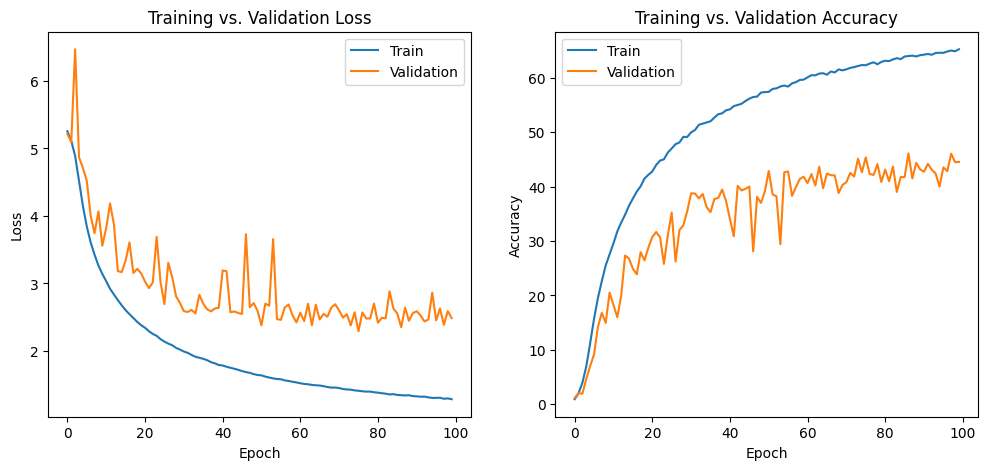

Accuracy: 0.3177
F1 Score: 0.3162
Precision: 0.3658
Recall: 0.3177
time: 20min 7s (started: 2025-03-10 04:30:12 +00:00)


In [ ]:
epochs = 100 #did not plato 80
lr = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(basic_cnn_gap_mp_model.parameters(), lr)

train_loss, val_loss, train_acc, val_acc = training_loop(
    basic_cnn_gap_mp_model, optimizer, criterion, epochs, train_loader, val_loader, is_clip=True ,non_blocking=True)

visualize_results(train_loss, val_loss, train_acc, val_acc)
accuracy, f1, precision, recall = generate_classification_report(basic_cnn_gap_mp_model, test_loader, device, non_blocking=True)

In [ ]:
model_filename = f"CNN-Basic_CNN_GAP_MP-{accuracy:.2f}"
save_model_weights(basic_cnn_gap_mp_model,model_filename)



# Experiment 2 - QuickTrain - Model Architecture designed for speed and efficiency.

This model, `QuickTrain`, is designed for efficient image classification, prioritizing speed and ease of training even on resource-constrained hardware like a standard laptop. It achieves this through a compact architecture inspired by MobileNet principles.

**Architecture:**

*   **Depthwise Separable Convolutions:** This is the cornerstone of the model's efficiency.  Instead of standard convolutions, `QuickTrain` uses depthwise separable convolutions, which drastically reduce the number of parameters and computations.  This is achieved by separating the convolution into two steps: a depthwise convolution that filters each input channel independently, and a pointwise convolution (1x1 convolution) that combines the outputs. This approach allows for building deeper networks with fewer resources.

*   **Aggressive Downsampling:** The model rapidly reduces the spatial dimensions of the feature maps through a combination of techniques. The very first convolutional layer (`conv1`) uses a stride of 2, immediately halving the input size.  Furthermore, *each* of the four convolutional blocks incorporates a 2x2 max pooling layer (also with a stride of 2), further reducing the feature map dimensions by half after each block.  This aggressive downsampling contributes significantly to the model's speed.

*   **Global Pooling:** Instead of flattening the feature maps and using large, dense fully connected layers, `QuickTrain` employs a global pooling layer (either Global Average Pooling or Global Max Pooling) after the final convolutional block.  This layer reduces each feature map to a *single* value, summarizing the presence of the feature across the entire spatial extent. This drastically reduces the number of parameters in the classification stage, leading to fewer computations and reduced risk of overfitting. It also provides some degree of translation invariance.

*   **Dropout Regularization:** To prevent overfitting, especially given the relatively small size of the model, dropout is applied before the fully connected layers.  Dropout randomly sets a fraction of neuron activations to zero during training, forcing the network to learn more robust and redundant representations. This improves generalization to unseen data.

*    **Two Fully Connected Layers:** While global pooling minimizes the parameters before the classification, QuickTrain utilizes *two* fully connected layers. The added `fc1` into the `fc2` layer provides important additional non-linearity to the model. This gives the model additional power over the original *SmallCNN* model.


**Training and Hyperparameters:**

*   **Optimizer:** AdamW (Adam with weight decay)
*   **Learning Rate:** 0.06 (3e-2)
*   **Loss Function:** Cross-Entropy Loss
*   **Epochs:** 10
*   **Scheduler:** CosineAnnealingWarmRestarts (T_0=10, T_mult=2, eta_min=1e-5) - This learning rate scheduler helps to find a better minimum and potentially escape local minima during training.
* **Weight Decay**: 1e-4 added in the optimizer for regularization
*   **Additional Notes:** Gradient clipping is used during training. PyTorch's `non_blocking=True` is utilized for optimized data transfer between CPU and GPU (if available).

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)
        self.bn_dw = nn.BatchNorm2d(in_channels)
        self.bn_pw = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn_dw(self.depthwise(x)))
        x = F.relu(self.bn_pw(self.pointwise(x)))
        return x

class QuickTrain(nn.Module):
    def __init__(self, num_classes=196, pooling_method="AVG"):  # Default to AVG
        super(QuickTrain, self).__init__()
        self.pooling_method = pooling_method

        # Aggressive downsampling in the first layer
        self.conv1 = nn.Conv2d(1, 8, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.block1 = self._make_block(8, 16)
        self.block2 = self._make_block(16, 32)
        self.block3 = self._make_block(32, 64)
        self.block4 = self._make_block(64, 128)

        self.global_pool = nn.AdaptiveMaxPool2d((1, 1)) if self.pooling_method == "MAX" else nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, num_classes)


    def _make_block(self, in_channels, out_channels):
        return nn.Sequential(
            DepthwiseSeparableConv(in_channels, out_channels, 3, stride=1, padding=1),
            nn.Dropout2d(0.05),
            DepthwiseSeparableConv(out_channels, out_channels, 3, stride=1, padding=1),
            nn.Dropout2d(0.05),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        self.dropout2 = nn.Dropout(0.5)
        x = self.fc2(x)
        return x


qiuck_train_model = QuickTrain()
qiuck_train_model.to(device)
print_params_count(qiuck_train_model)

Total number of parameters: 59492
Total number of trainable parameters: 59492
time: 43.1 ms (started: 2025-03-10 13:11:31 +00:00)


Epoch 1, Learning Rate: 0.001000
Epoch [1/275], Loss: 5.2716, Validation Loss: 5.2565, Validation Accuracy: 0.82%


Epoch 2, Learning Rate: 0.001000
Epoch [2/275], Loss: 5.2172, Validation Loss: 5.2325, Validation Accuracy: 1.07%


Epoch 3, Learning Rate: 0.001000
Epoch [3/275], Loss: 5.1785, Validation Loss: 5.1940, Validation Accuracy: 1.25%


Epoch 4, Learning Rate: 0.001000
Epoch [4/275], Loss: 5.1285, Validation Loss: 5.1512, Validation Accuracy: 1.19%


Epoch 5, Learning Rate: 0.001000
Epoch [5/275], Loss: 5.0658, Validation Loss: 5.0543, Validation Accuracy: 1.76%


...

Epoch 271, Learning Rate: 0.001000
Epoch [271/275], Loss: 2.3242, Validation Loss: 1.6451, Validation Accuracy: 56.46%


Epoch 272, Learning Rate: 0.001000
Epoch [272/275], Loss: 2.3157, Validation Loss: 1.6638, Validation Accuracy: 56.69%


Epoch 273, Learning Rate: 0.001000
Epoch [273/275], Loss: 2.3059, Validation Loss: 1.6532, Validation Accuracy: 56.15%


Epoch 274, Learning Rate: 0.001000
Epoch [274/275], Loss: 2.3051, Validation Loss: 1.6485, Validation Accuracy: 55.81%


Epoch 275, Learning Rate: 0.001000
Epoch [275/275], Loss: 2.3181, Validation Loss: 1.6433, Validation Accuracy: 55.82%


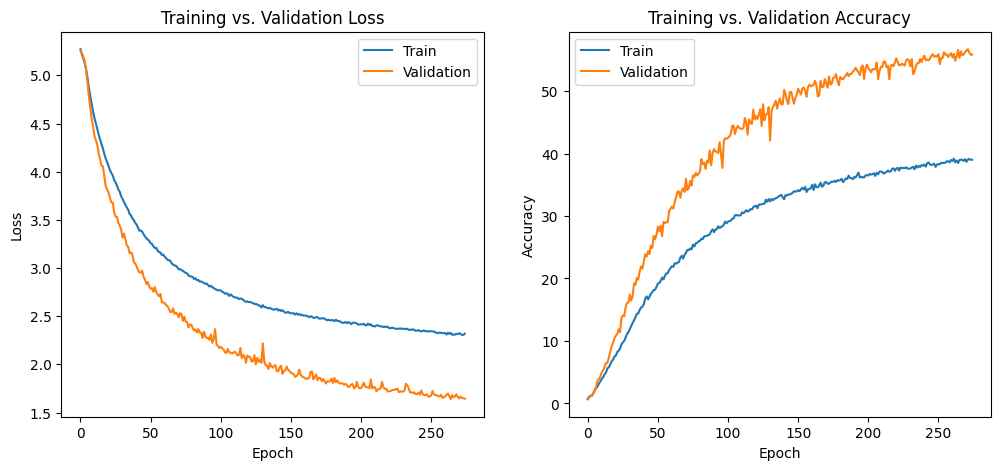

Accuracy: 0.5030
F1 Score: 0.4969
Precision: 0.5228
Recall: 0.5030
time: 1h 29min 35s (started: 2025-03-10 13:11:35 +00:00)


In [ ]:
epochs = 275
lr = 1e-3

optimizer = optim.AdamW(qiuck_train_model.parameters(), lr=lr, betas=(0.9,0.999), weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_loss, val_loss, train_acc, val_acc = training_loop(
    qiuck_train_model, optimizer, criterion, epochs, train_loader, val_loader, is_clip=True,non_blocking=True)

visualize_results(train_loss, val_loss, train_acc, val_acc)
accuracy, f1, precision, recall = generate_classification_report(qiuck_train_model, test_loader, device, non_blocking=True)

In [ ]:
model_filename = f"CNN-QuickTrain-{accuracy:.2f}"
save_model_weights(qiuck_train_model,model_filename)

# Experiment 3 - BiggerIsBetter? - A bigger and deepr version of the QuickTrain model



This model, `BiggerIsBetter`, is a refined (bigger and deeper) version of the `QiuckTrain`.

**Architecture:**

*   **Four Convolutional Blocks:** The core of the network consists of four convolutional blocks.  Each block contains two depthwise separable convolutions.
    *   **Downsampling within Blocks:** Downsampling (stride=2) is integrated into the *first* depthwise separable convolution of the *first three* blocks. The last block dose *not* downsample. This eliminates the need for separate `MaxPool2d` layers within the blocks, streamlining the architecture.
    *   **Consistent Channel Doubling:** The number of channels doubles consistently across the first three blocks (12 -> 24 -> 48 -> 96), ending at 192 in the fourth block.

*   **Global Pooling Choice:** The model supports either Global Average Pooling (GAP) or Global Max Pooling before the final classification layer, with Max Pooling as the default.  This provides flexibility in how feature maps are summarized.

*   **Regularization:**
    *   Batch normalization is applied after each convolutional layer and before the ReLU activation in the fully connected layers, promoting stable training and better generalization.
    *   Dropout (rate of 0.4) is used after the global pooling layer and *between* the fully connected layers to prevent overfitting.

*   **Three Fully Connected Layers:**  A three-layer fully connected network (192 -> 128 -> 64 -> `num_classes`) performs the final classification. The smaller size of these layers, compared to previous versions, contributes to the model's overall efficiency.

**Training and Hyperparameters:**

*   **Optimizer:** AdamW (Adam with weight decay)
*   **Learning Rate:** 1e-3 (0.001)
*   **Loss Function:** Cross-Entropy Loss
*   **Epochs:** 20
*   **Scheduler:** CosineAnnealingWarmRestarts (T_0=10, T_mult=2, eta_min=1e-5) - This learning rate scheduler helps to improve training by cyclically varying the learning rate.
*   **Weight Decay:** 1e-4 (included in the AdamW optimizer) - Provides L2 regularization.
*   **Additional Notes:** Gradient clipping is used during training. PyTorch's `non_blocking=True` is utilized for optimized data transfer (if using a GPU).


In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, extra_depth=False):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)
        self.bn_dw = nn.BatchNorm2d(in_channels)
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.extra_depth = extra_depth

        if extra_depth:
            self.extra_dw = nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding, groups=out_channels)
            self.extra_pw = nn.Conv2d(out_channels, out_channels, 1)
            self.bn_extra_dw = nn.BatchNorm2d(out_channels)
            self.bn_extra_pw = nn.BatchNorm2d(out_channels)
            self.dropout_extra = nn.Dropout2d(0.05)

    def forward(self, x):
        x = F.relu(self.bn_dw(self.depthwise(x)))
        x = F.relu(self.bn_pw(self.pointwise(x)))

        if self.extra_depth:
            x = F.relu(self.bn_extra_dw(self.extra_dw(x)))
            x = F.relu(self.bn_extra_pw(self.extra_pw(x)))
            x = self.dropout_extra(x)
        return x

class BiggerIsBetter(nn.Module):
    def __init__(self, num_classes=196, pooling_method="AVG"):
        super(BiggerIsBetter, self).__init__()
        self.pooling_method = pooling_method

        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout_conv1 = nn.Dropout2d(0.1)

        # Consistent channel doubling, added depth within DepthwiseSeparableConv
        self.block1 = self._make_block(32, 64, stride=2, extra_depth=True)
        self.block2 = self._make_block(64, 128, stride=2, extra_depth=True)
        self.block3 = self._make_block(128, 256, stride=2, extra_depth=True)
        self.block4 = self._make_block(256, 512, stride=1, extra_depth=False) # No extra depth/downsampling

        # Global Pooling
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1)) if self.pooling_method == "MAX" else nn.AdaptiveAvgPool2d((1, 1))

        self.dropout1 = nn.Dropout(0.5)

        # Three FC layers with BatchNorm and Dropout
        self.fc1 = nn.Linear(512, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, num_classes)

    def _make_block(self, in_channels, out_channels, stride=1, extra_depth=False):
        return nn.Sequential(
            DepthwiseSeparableConv(in_channels, out_channels, 3, stride=stride, padding=1, extra_depth=extra_depth),
            nn.Dropout2d(0.05),
            DepthwiseSeparableConv(out_channels, out_channels, 3, stride=1, padding=1, extra_depth=extra_depth),
            nn.Dropout2d(0.05),
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout_conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout2(x)
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout3(x)
        x = self.fc3(x)
        return x

bigger_is_better_model = BiggerIsBetter()
bigger_is_better_model.to(device)
print_params_count(bigger_is_better_model)

Total number of parameters: 921412
Total number of trainable parameters: 921412
time: 61.3 ms (started: 2025-03-10 10:31:48 +00:00)


Epoch 1, Learning Rate: 0.001000
Epoch [1/300], Loss: 5.2881, Validation Loss: 5.2650, Validation Accuracy: 0.45%


Epoch 2, Learning Rate: 0.001000
Epoch [2/300], Loss: 5.1919, Validation Loss: 5.1495, Validation Accuracy: 1.42%


Epoch 3, Learning Rate: 0.001000
Epoch [3/300], Loss: 5.0946, Validation Loss: 5.0674, Validation Accuracy: 1.75%


Epoch 4, Learning Rate: 0.001000
Epoch [4/300], Loss: 4.9891, Validation Loss: 4.9096, Validation Accuracy: 2.90%


Epoch 5, Learning Rate: 0.001000
Epoch [5/300], Loss: 4.8359, Validation Loss: 4.6691, Validation Accuracy: 3.86%


...

Epoch 296, Learning Rate: 0.001000
Epoch [296/300], Loss: 0.2779, Validation Loss: 0.6471, Validation Accuracy: 85.36%


Epoch 297, Learning Rate: 0.001000
Epoch [297/300], Loss: 0.2815, Validation Loss: 0.6357, Validation Accuracy: 85.75%


Epoch 298, Learning Rate: 0.001000
Epoch [298/300], Loss: 0.2798, Validation Loss: 0.6572, Validation Accuracy: 85.36%


Epoch 299, Learning Rate: 0.001000
Epoch [299/300], Loss: 0.2790, Validation Loss: 0.6356, Validation Accuracy: 85.62%


Epoch 300, Learning Rate: 0.001000
Epoch [300/300], Loss: 0.2815, Validation Loss: 0.6333, Validation Accuracy: 85.83%


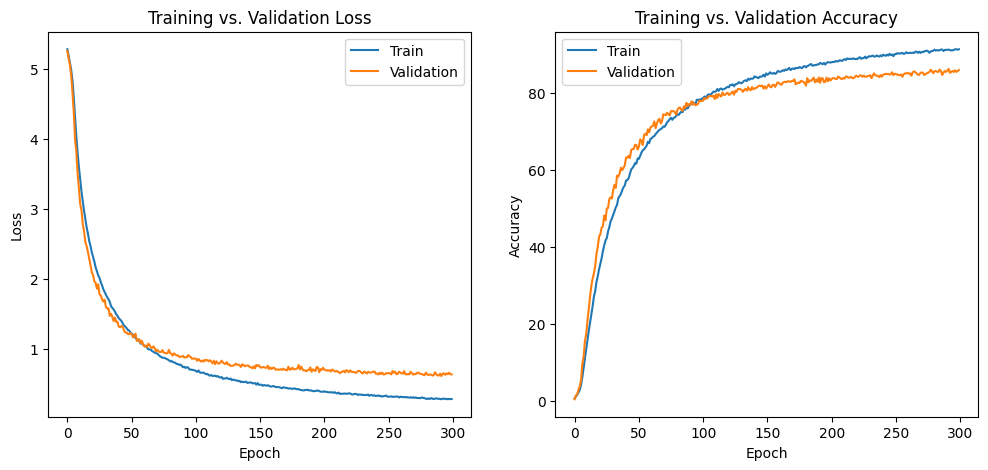

Accuracy: 0.6456
F1 Score: 0.6446
Precision: 0.6580
Recall: 0.6456
time: 2h 25min 57s (started: 2025-03-10 10:31:52 +00:00)


In [ ]:
epochs = 300
lr = 1e-3

optimizer = optim.AdamW(bigger_is_better_model.parameters(), lr=lr, betas=(0.9,0.999), weight_decay=5e-5)
criterion = nn.CrossEntropyLoss()

train_loss, val_loss, train_acc, val_acc = training_loop(
    bigger_is_better_model, optimizer, criterion, epochs, train_loader, val_loader, is_clip=True,non_blocking=True)

visualize_results(train_loss, val_loss, train_acc, val_acc)
accuracy, f1, precision, recall = generate_classification_report(bigger_is_better_model, test_loader, device)

In [ ]:
model_filename = f"CNN-BiggerIsBetter-{accuracy:.2f}"
save_model_weights(bigger_is_better_model,model_filename)

Model saved to /content/./saved_models/CNN-BiggerIsBetter-0.65
time: 89.1 ms (started: 2025-03-10 13:02:33 +00:00)


# Test Best Model

## Instalations

In [ ]:
%%capture
%pip install torch torchvision matplotlib pillow scipy

time: 3.41 s (started: 2025-03-10 15:13:29 +00:00)


In [ ]:
!gdown 11UWKeRh0PCd2l-JAoTIf9hSDf7NooOL4 # bigger is better weights
!gdown 1imXzZ5_lLbYg8W1jmP4q_TcEkUWlUI6a # cars_annos.mat

Downloading...
From: https://drive.google.com/uc?id=11UWKeRh0PCd2l-JAoTIf9hSDf7NooOL4
To: /content/CNN-BiggerIsBetter-0.65
100% 3.81M/3.81M [00:00<00:00, 117MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1imXzZ5_lLbYg8W1jmP4q_TcEkUWlUI6a
From (redirected): https://drive.google.com/uc?id=1imXzZ5_lLbYg8W1jmP4q_TcEkUWlUI6a&confirm=t&uuid=2f6520b7-84d4-49b3-8e77-d4cde0326751
To: /content/cars_annos.mat
100% 394k/394k [00:00<00:00, 24.5MB/s]
time: 10.2 s (started: 2025-03-10 15:13:33 +00:00)


## Test dependencies

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import scipy.io
from google.colab import files


time: 11.1 s (started: 2025-03-10 15:14:19 +00:00)


In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, extra_depth=False):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)
        self.bn_dw = nn.BatchNorm2d(in_channels)
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.extra_depth = extra_depth

        if extra_depth:
            self.extra_dw = nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding, groups=out_channels)
            self.extra_pw = nn.Conv2d(out_channels, out_channels, 1)
            self.bn_extra_dw = nn.BatchNorm2d(out_channels)
            self.bn_extra_pw = nn.BatchNorm2d(out_channels)
            self.dropout_extra = nn.Dropout2d(0.05)

    def forward(self, x):
        x = F.relu(self.bn_dw(self.depthwise(x)))
        x = F.relu(self.bn_pw(self.pointwise(x)))

        if self.extra_depth:
            x = F.relu(self.bn_extra_dw(self.extra_dw(x)))
            x = F.relu(self.bn_extra_pw(self.extra_pw(x)))
            x = self.dropout_extra(x)
        return x

class BiggerIsBetter(nn.Module):
    def __init__(self, num_classes=196, pooling_method="AVG"):
        super(BiggerIsBetter, self).__init__()
        self.pooling_method = pooling_method

        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout_conv1 = nn.Dropout2d(0.1)

        # Consistent channel doubling, added depth within DepthwiseSeparableConv
        self.block1 = self._make_block(32, 64, stride=2, extra_depth=True)
        self.block2 = self._make_block(64, 128, stride=2, extra_depth=True)
        self.block3 = self._make_block(128, 256, stride=2, extra_depth=True)
        self.block4 = self._make_block(256, 512, stride=1, extra_depth=False) # No extra depth/downsampling

        # Global Pooling
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1)) if self.pooling_method == "MAX" else nn.AdaptiveAvgPool2d((1, 1))

        self.dropout1 = nn.Dropout(0.5)

        # Three FC layers with BatchNorm and Dropout
        self.fc1 = nn.Linear(512, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, num_classes)

    def _make_block(self, in_channels, out_channels, stride=1, extra_depth=False):
        return nn.Sequential(
            DepthwiseSeparableConv(in_channels, out_channels, 3, stride=stride, padding=1, extra_depth=extra_depth),
            nn.Dropout2d(0.05),
            DepthwiseSeparableConv(out_channels, out_channels, 3, stride=1, padding=1, extra_depth=extra_depth),
            nn.Dropout2d(0.05),
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout_conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout2(x)
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout3(x)
        x = self.fc3(x)
        return x


time: 2.99 ms (started: 2025-03-10 15:14:30 +00:00)


In [ ]:
def grayscale_normalization(output_size=(160, 160)):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(output_size, interpolation=transforms.InterpolationMode.LANCZOS),
        transforms.ToTensor()
    ])

def test_model_with_image(model, filename, normalize_fn, class_names_list ):
    """
    Tests the model with a single image, displays the original image,
    and a chart with the top predictions.
    """
    image = Image.open(filename).convert('RGB')
    normalized_image = normalize(image)
    input_tensor = normalized_image.unsqueeze(0)  # Add batch dimension
    if not input_tensor.is_cuda and torch.cuda.is_available():
      input_tensor = input_tensor.cuda()

    with torch.no_grad():
      output = bigger_is_better_model(input_tensor)
      probabilities = torch.nn.functional.softmax(output[0], dim=0)
      topk_values, topk_indices = torch.topk(probabilities, 3)

    # Display original image and prediction chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 7]}) # 30% and 70%

    # Display original image
    ax1.imshow(image)
    ax1.set_title("Original Image")
    ax1.axis('off')

    # Display prediction chart
    ax2.bar(range(len(topk_values)), topk_values.cpu().numpy())
    ax2.set_xticks(range(len(topk_values)))
    ax2.set_xticklabels([f"{class_names_list[i]}" for i in topk_indices.cpu().numpy()], rotation=45, ha='right')
    ax2.set_title("Top Predictions")
    ax2.set_xlabel("Class")
    ax2.set_ylabel("Probability")

    plt.show()

def test_model_upload_images(model, normalize_fn, class_names_list):
    """
    Uploads images and tests the model with each.
    """
    uploaded = files.upload()

    for filename in uploaded.keys():
        test_model_with_image(model, filename, normalize_fn, class_names_list)


time: 2.65 ms (started: 2025-03-10 15:14:30 +00:00)


In [ ]:
class_names = scipy.io.loadmat('./cars_annos.mat')['class_names']
class_names_list = [name[0] for name in class_names[0]]
num_classes = len(class_names_list)

time: 383 ms (started: 2025-03-10 15:14:30 +00:00)


## Play with the model

<ipython-input-12-302b57370494>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bigger_is_better_model.load_state_dict(torch.load(f'CNN-BiggerIsBetter-0.65', map_location=d

Saving 00001.jpg to 00001.jpg


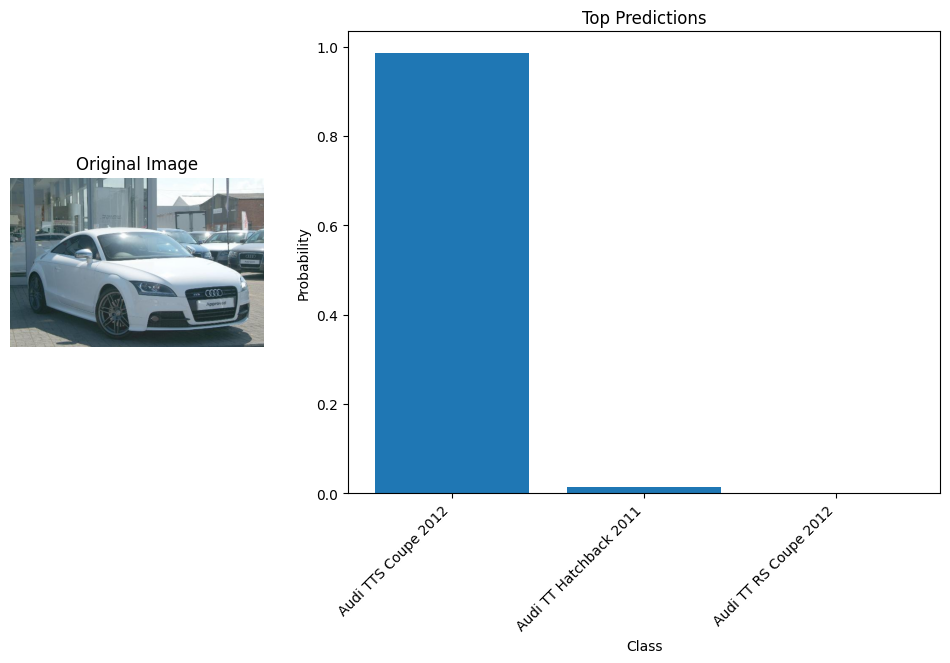

time: 11.7 s (started: 2025-03-10 15:14:47 +00:00)


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

normalize = grayscale_normalization()

bigger_is_better_model = BiggerIsBetter()
bigger_is_better_model.to(device)
bigger_is_better_model.load_state_dict(torch.load(f'CNN-BiggerIsBetter-0.65', map_location=device))
bigger_is_better_model.eval()

test_model_upload_images(bigger_is_better_model, normalize, class_names_list)
